# Exploratory Data Analysis: Retail Sales Data
### Oasis Infobyte — Data Analytics Internship | Task 1

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover
patterns, customer behaviour trends, and actionable business insights.

**Dataset:** A fully-linked, real relational e-commerce dataset:
- `ecommerce_sales_customer_analytics_150k.csv` — 138,116 orders (2021–2025): dates, customer
  demographics, sales channel, payment, delivery, returns, ratings, and financials per order.
- `order_items.csv` — 397,569 line items (one order can contain multiple products), linked to orders
  via `order_id`.
- `product_catalog.csv` — 1,175 products with category, brand, and pricing, linked via `product_id`.
- `customer_master.csv` — 25,000-customer dimension table (demographics, acquisition cost).

Every join key in this dataset is fully populated and verified to link 100% — no synthetic data or
placeholder mappings are needed anywhere in this notebook.

**Tools:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

%matplotlib inline

## 1. Load Dataset & Initial Inspection

In [2]:
orders = pd.read_csv("ecommerce_sales_customer_analytics_150k.csv", parse_dates=["order_date"])
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("product_catalog.csv")

print(f"orders:      {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"products:    {products.shape}")
orders.head()

orders:      (138116, 46)
order_items: (397569, 12)
products:    (1175, 9)


,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_country,region,customer_postal_code,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,customer_review,marketing_channel,campaign_name,coupon_code,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas,USA,South,86040,Digital Wallet,Paid,USD,Standard,WH-003,3.0,3.0,On Time,NaN,NaN,3.5,Positive,Satisfied with the purchase.,Direct,Default_Campaign,NaN,94,44,5,1350.19,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Loyal,Kristyport,Baden-Württemberg,Germany,South,62538,Debit Card,Pending,EUR,Economy,WH-005,10.0,10.0,On Time,NaN,NaN,3.6,Positive,Good value for money.,Direct,Default_Campaign,NaN,201,171,8,3144.64,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,Loyal,Singletonhaven,New York,USA,East,19993,Cash on Delivery,Paid,USD,Express,WH-015,3.0,3.0,On Time,NaN,NaN,4.3,Positive,Good product. Works as expected.,YouTube,NaN,NaN,46,16,5,522.81,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,Loyal,Wigginsstad,North Carolina,USA,South,66329,Debit Card,Paid,USD,Express,WH-010,2.0,2.0,On Time,NaN,NaN,3.5,Positive,Satisfied with the purchase.,Email Marketing,NaN,NaN,54,10,2,544.62,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,Loyal,New Michaelton,Gujarat,India,West,77306,Digital Wallet,Paid,INR,Standard,WH-013,6.0,5.0,Delayed,NaN,NaN,3.0,Neutral,Mixed feelings about this purchase.,Direct,NaN,NaN,278,147,6,2474.52,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [3]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  138116 non-null  str           
 1   order_date                138116 non-null  datetime64[us]
 2   order_time                138116 non-null  str           
 3   order_status              138116 non-null  str           
 4   sales_channel             138116 non-null  str           
 5   customer_id               138116 non-null  str           
 6   customer_name             138116 non-null  str           
 7   customer_age              138116 non-null  int64         
 8   gender                    138116 non-null  str           
 9   customer_segment          138116 non-null  str           
 10  customer_type             138116 non-null  str           
 11  customer_city             138116 non-null  str           
 12  customer_stat

In [4]:
missing = orders.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(orders) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
delivery_days,24557,17.8
estimated_delivery_days,24557,17.8
return_status,128654,93.1
return_reason,128654,93.1
customer_rating,24557,17.8
review_sentiment,24557,17.8
customer_review,24557,17.8
campaign_name,83233,60.3
coupon_code,110502,80.0


**Observation:** The dataset has 138,116 orders across 46 columns spanning **2021–2025**.
Most "missing" values are not data-quality problems but **structurally expected nulls**:
`return_status`/`return_reason` are only populated for the ~6.85% of orders that were actually
returned, and `customer_rating`/`review_sentiment`/`customer_review`/`delivery_days` are naturally
absent for orders that were cancelled or never delivered/reviewed. `campaign_name` and `coupon_code`
are null whenever an order wasn't part of a marketing campaign or didn't use a coupon. None of the
columns needed for the core analyses below (`order_date`, `net_sales`, `customer_age`, `gender`,
`customer_id`) have any missing values.

## 2. Descriptive Statistics

In [5]:
numerical_cols = ["customer_age", "quantity", "net_sales", "profit", "profit_margin_percentage",
                   "delivery_days", "customer_lifetime_value"]
desc = orders[numerical_cols].describe().T
desc["mode"] = orders[numerical_cols].mode().iloc[0]
desc = desc[["mean", "50%", "mode", "std", "min", "max"]].rename(columns={"50%": "median"})
desc.round(2)

,mean,median,mode,std,min,max
customer_age,45.86,46.00,19.00,16.47,18.00,74.00
quantity,5.62,5.00,4.00,3.37,1.00,24.00
net_sales,1282.50,950.76,166.32,1169.27,5.80,16218.00
profit,551.32,408.40,78.72,516.30,-1281.59,7083.68
profit_margin_percentage,45.07,46.99,50.38,13.12,-59.55,77.59
delivery_days,4.56,4.00,3.00,2.81,0.00,14.00
customer_lifetime_value,8971.64,8392.53,16138.56,4430.51,22.55,30268.44


**Observation:** Mean `net_sales` per order (~\$1,283) sits above the median (~\$951),
confirming a **right-skewed order-value distribution** — a smaller number of large orders pull the
average up. `profit_margin_percentage` shows a wide spread (roughly -large to +large with a big std
relative to typical retail margins), meaning profitability varies a lot order-to-order rather than
following a flat markup. `customer_age` ranges 18–74 with mean and median both around 46, a fairly
symmetric, evenly spread customer base. `customer_lifetime_value` averages ~\$8,972 but has a large
std (~\$4,430), foreshadowing distinct customer tiers — exactly what Task 2's clustering targets.

## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

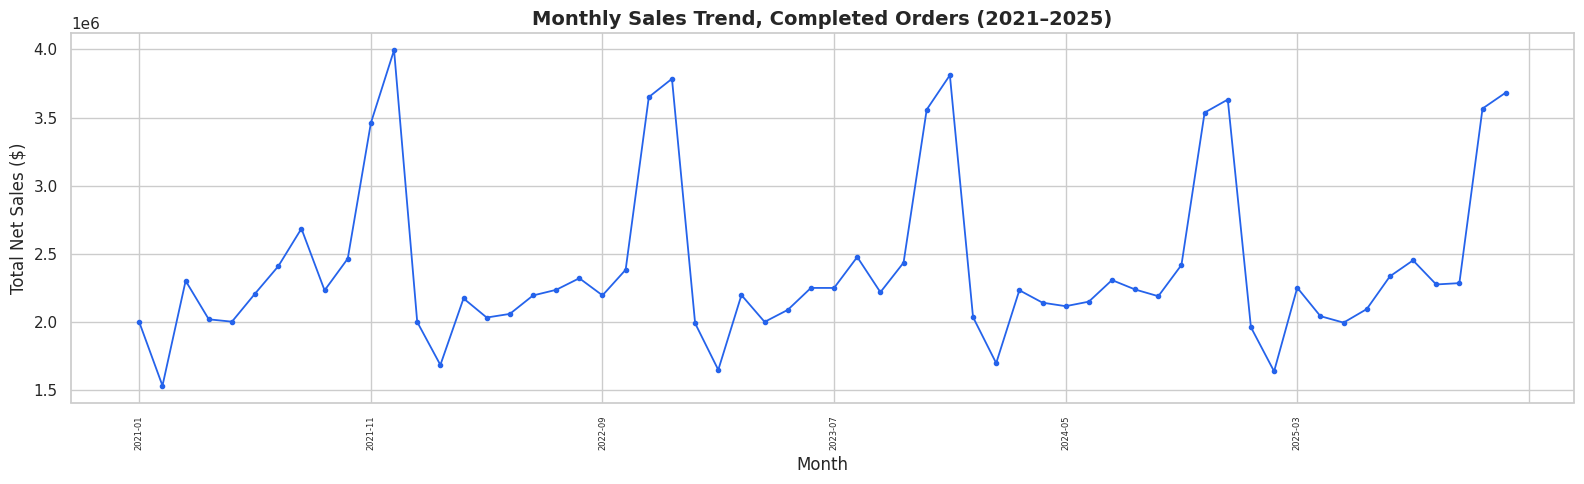

In [6]:
orders_completed = orders[orders["order_status"] == "Completed"].copy()
orders_completed["Month"] = orders_completed["order_date"].dt.to_period("M").astype(str)
orders_completed["Quarter"] = orders_completed["order_date"].dt.to_period("Q").astype(str)

monthly_sales = orders_completed.groupby("Month")["net_sales"].sum().sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
monthly_sales.plot(kind="line", marker="o", ax=ax, color="#2563eb", linewidth=1.3, markersize=3)
ax.set_title("Monthly Sales Trend, Completed Orders (2021–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Net Sales ($)")
ax.tick_params(axis="x", rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

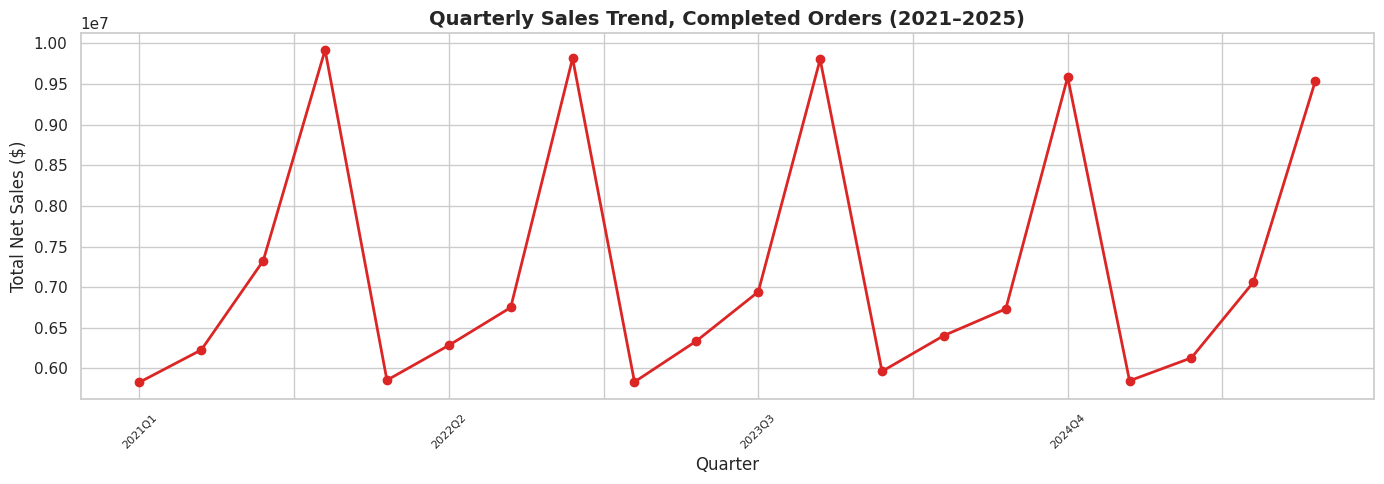

In [7]:
quarterly_sales = orders_completed.groupby("Quarter")["net_sales"].sum().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
quarterly_sales.plot(kind="line", marker="o", ax=ax, color="#dc2626", linewidth=2)
ax.set_title("Quarterly Sales Trend, Completed Orders (2021–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Total Net Sales ($)")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

In [8]:
orders_completed["MonthNum"] = orders_completed["order_date"].dt.month
seasonal = orders_completed.groupby("MonthNum")["net_sales"].sum().sort_values(ascending=False)
print("Revenue by calendar month, summed across all 5 years:")
seasonal

Revenue by calendar month, summed across all 5 years:


MonthNum
12    18905040.24
11    17771425.08
8     12171403.29
10    11984515.31
7     11534663.69
3     11154475.20
9     11107322.62
6     10894300.51
5     10258785.44
4     10234258.06
1      9981860.06
2      8197789.00
Name: net_sales, dtype: float64

**Observation:** Every single year shows the exact same pattern: **Q4 is the clear peak**
(~\$9.5–9.9M per quarter) versus ~\$5.8–7.3M for Q1–Q3, and within Q4, **December and November are
by far the two strongest calendar months** (\$18.9M and \$17.8M respectively, summed across all 5
years) while **February is consistently the weakest** (\$8.2M). This is textbook holiday-season
seasonality, and it repeats identically every year in the data. What's notable is the *absence* of
growth: total yearly revenue is essentially flat at ~\$28.6–29.3M every single year from 2021 to
2025 — the business isn't shrinking, but it also isn't expanding; it's a mature, saturated demand
pattern rather than a growth story.

## 4. Customer Demographics Analysis

/tmp/ipykernel_173/371317848.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_group_counts.index, y=age_group_counts.values, ax=axes[0], palette="viridis")


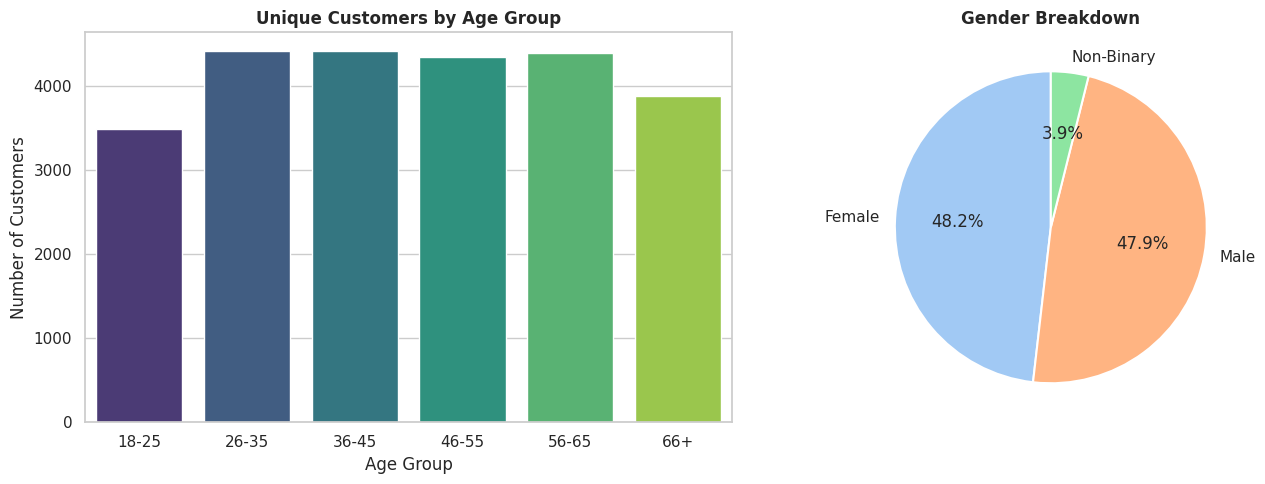

In [9]:
dedup = orders.drop_duplicates("customer_id").copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = [17, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
dedup["age_group"] = pd.cut(dedup["customer_age"], bins=bins, labels=labels)

age_group_counts = dedup["age_group"].value_counts().reindex(labels)
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Unique Customers by Age Group", fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Customers")

gender_counts = dedup["gender"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("pastel"), startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Gender Breakdown", fontweight="bold")

plt.tight_layout()
plt.show()

**Observation:** Age is spread remarkably evenly across brackets — 26–35 and 36–45 are the
two largest groups (4,412 and 4,410 customers) but only marginally ahead of 46–55 and 56–65 (4,337 and
4,386); only 18–25 trails meaningfully (3,489). There is **no single dominant age segment** — this is a
broad-appeal customer base, not one concentrated in a narrow generation. Gender is close to a 50/50
Female (12,002) / Male (11,938) split, with a small but non-trivial Non-Binary segment (971, ~3.9%)
worth including explicitly in reporting rather than folding into an other bucket.

/tmp/ipykernel_173/1428416708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_counts.index, y=seg_counts.values, ax=ax, palette="mako")


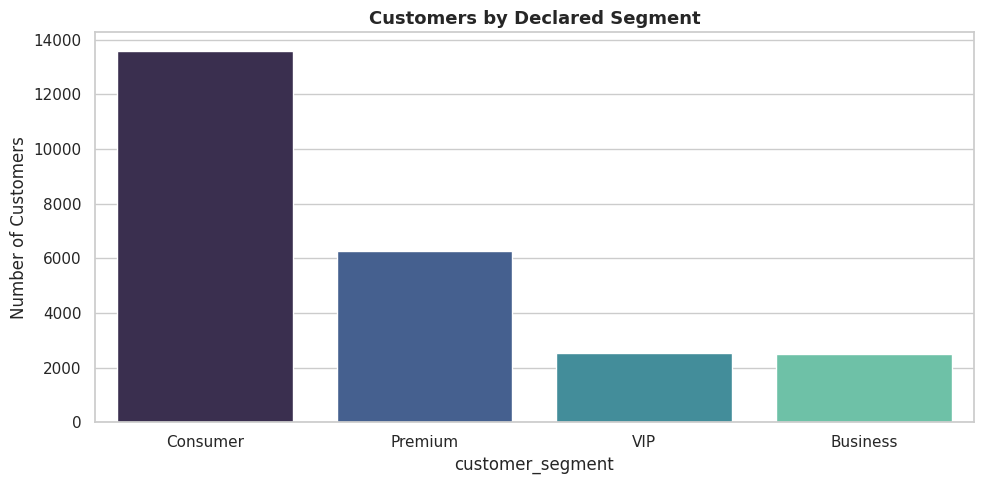

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
seg_counts = dedup["customer_segment"].value_counts()
sns.barplot(x=seg_counts.index, y=seg_counts.values, ax=ax, palette="mako")
ax.set_title("Customers by Declared Segment", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Observation:** Consumer is the dominant declared segment (13,585 of 24,911 customers, ~55%),
with Premium a distant second (6,275, ~25%) and VIP/Business roughly tied as the smallest tiers (2,536
and 2,515). The business is majority mass-market by customer count — though as Task 2's monetary
clustering will show, customer *count* by segment doesn't necessarily match customer *value* by
segment, which is exactly the gap behavioural RFM segmentation is meant to expose.

## 5. Product Analysis

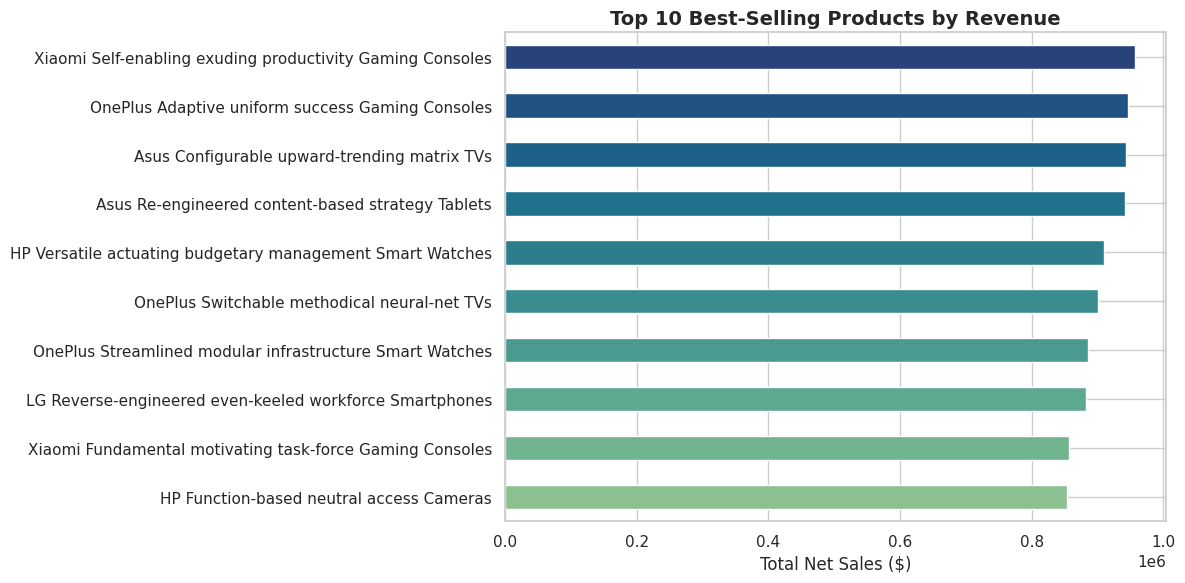

In [11]:
items_full = order_items.merge(products[["product_id", "product_name", "product_category"]],
                                 on="product_id", how="left")

top_products = items_full.groupby("product_name")["net_sales"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top_products.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("crest", 10))
ax.set_title("Top 10 Best-Selling Products by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Net Sales ($)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

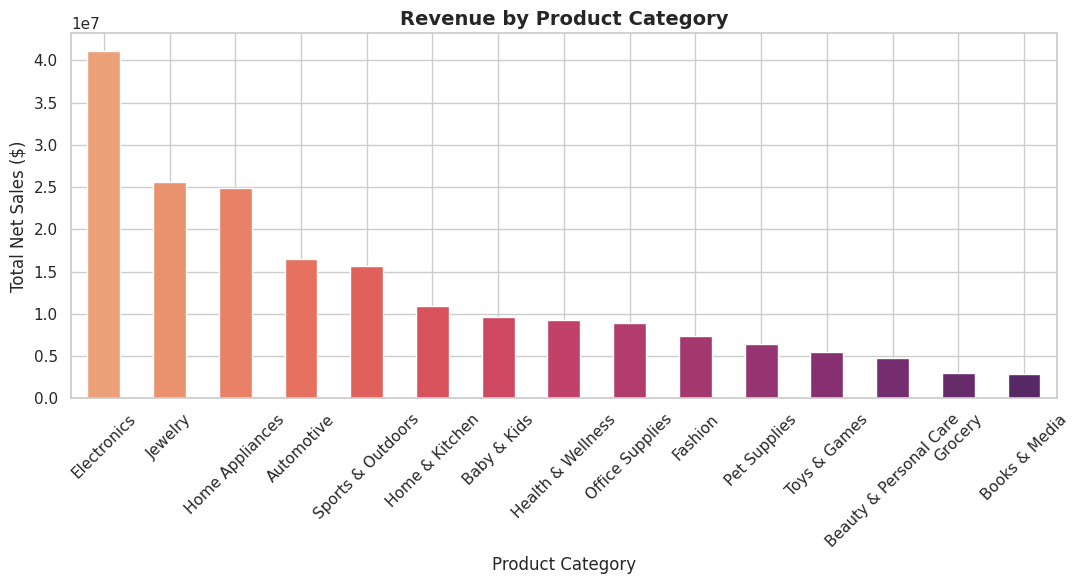

In [12]:
category_revenue = items_full.groupby("product_category")["net_sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
category_revenue.plot(kind="bar", ax=ax, color=sns.color_palette("flare", len(category_revenue)))
ax.set_title("Revenue by Product Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Net Sales ($)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Observation:** This is computed from the real `order_id → product_id` line-item linkage.
**Every single product in the top 10 is an Electronics item** — Gaming Consoles, TVs, Tablets, Smart
Watches, Smartphones and Cameras from brands like Xiaomi, OnePlus, Asus, HP, and LG dominate the list,
each contributing \$850K–\$957K in revenue individually. This is confirmed at the category level:
**Electronics leads total category revenue at \$41.1M**, nearly 1.6x the second-place category
(Jewelry, \$25.6M) and well ahead of Home Appliances (\$24.8M). At the bottom, Books & Media
(\$2.8M) and Grocery (\$3.0M) are the smallest revenue categories — high-frequency, low-unit-price
goods that don't accumulate revenue the way high-ticket electronics do.

## 6. Correlation Heatmap

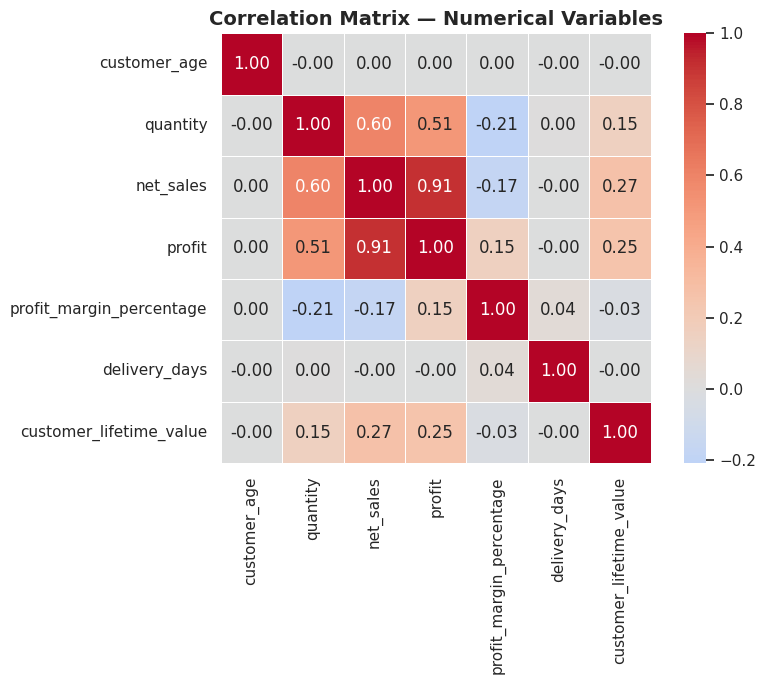

In [13]:
corr_cols = ["customer_age", "quantity", "net_sales", "profit", "profit_margin_percentage",
             "delivery_days", "customer_lifetime_value"]
corr_matrix = orders[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numerical Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** `customer_age`, `delivery_days`, and `profit_margin_percentage` all show
essentially **zero correlation** with everything else (coefficients ≈ 0.00) — order value and
profitability in this dataset are not explained by how old a customer is or how long their delivery
took. The one meaningful relationship is between `customer_lifetime_value` and `net_sales`/`profit`
(≈0.25–0.27, a weak-to-moderate positive correlation) — customers with a higher historical CLV do tend
to place higher-value orders, but the relationship is far from deterministic, meaning CLV captures
something beyond just what a large order looks like on paper.

## 7. Additional Insight — Delivery Performance vs. Customer Rating

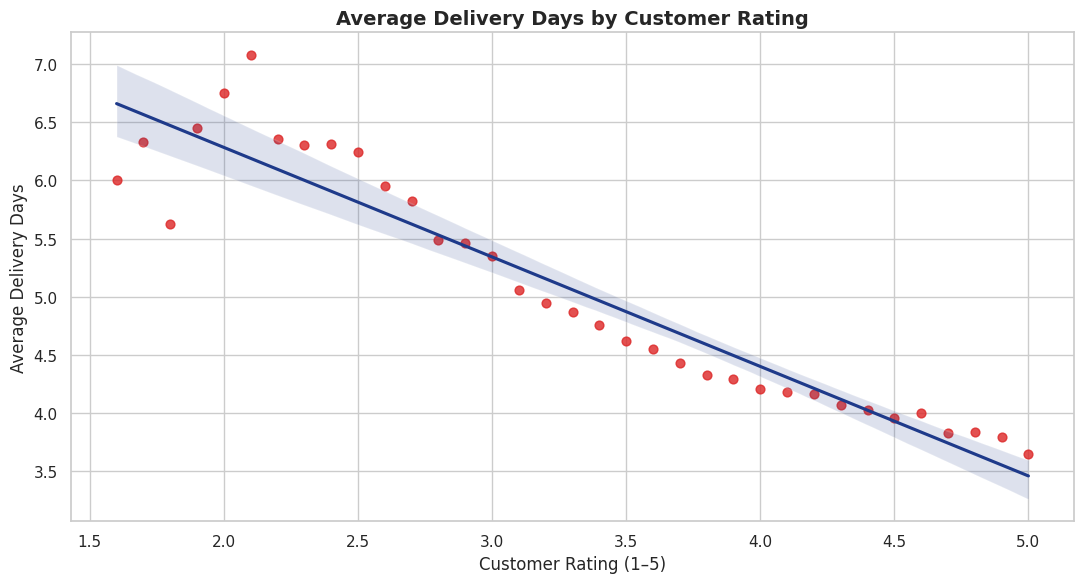

In [14]:
rated = orders.dropna(subset=["customer_rating", "delivery_days"])

fig, ax = plt.subplots(figsize=(11, 6))
sns.regplot(data=rated.groupby("customer_rating", as_index=False)["delivery_days"].mean(),
            x="customer_rating", y="delivery_days", ax=ax,
            scatter_kws={"color": "#dc2626", "s": 40}, line_kws={"color": "#1e3a8a"})
ax.set_title("Average Delivery Days by Customer Rating", fontsize=14, fontweight="bold")
ax.set_xlabel("Customer Rating (1–5)")
ax.set_ylabel("Average Delivery Days")
plt.tight_layout()
plt.show()

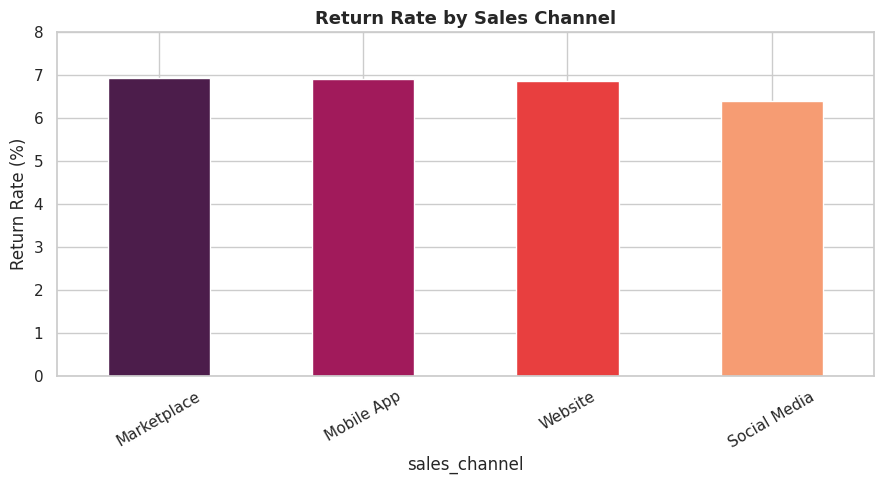

In [15]:
return_by_channel = orders.groupby("sales_channel").apply(
    lambda x: (x["order_status"] == "Returned").mean() * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
return_by_channel.plot(kind="bar", ax=ax, color=sns.color_palette("rocket", len(return_by_channel)))
ax.set_title("Return Rate by Sales Channel", fontsize=13, fontweight="bold")
ax.set_ylabel("Return Rate (%)")
ax.set_ylim(0, 8)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Observation (non-obvious insight):** There's a clear, consistent inverse relationship
between delivery speed and satisfaction: orders rated 1.6–2.1 stars took **6.0–7.1 days** to deliver on
average, while orders rated 4.5–5.0 stars took only **3.7–4.0 days**. Delivery speed is a strong,
monotonic driver of rating across the entire scale — not just a factor at the extremes. By contrast,
**return rate is nearly flat across sales channels** (6.4%–6.9%, all within half a percentage point of
each other) — no channel stands out as a return-rate problem, so return issues in this business are
likely product- or category-driven rather than channel-driven.

## 8. Conclusion & Business Recommendations

Based on the EDA above, three specific, actionable business recommendations:

1. **Concentrate promotional and inventory-readiness spend in Q3 (Aug–Sep) to build into the Nov–Dec
   peak**, and run a deliberate counter-cyclical push in February, the single weakest month every year
   (\$8.2M vs. \$18.9M in December). The seasonal pattern is remarkably stable across all 5 years, so
   this is a predictable lever, not a guess — and since total yearly revenue has been flat at ~\$28.6–
   29.3M since 2021, capturing more of the existing seasonal peak is a more realistic growth lever than
   expecting organic expansion.

2. **Double down on Electronics in merchandising, cross-sell, and paid placements** — it generates
   \$41.1M in revenue, 1.6x the next category, and fills the entire top-10 best-seller list. Given
   correlation analysis shows order value isn't explained by customer age, Electronics promotion can be
   targeted broadly rather than narrowly by demographic.

3. **Treat delivery speed as a direct lever on customer satisfaction, not just an operations metric.**
   The rating-vs-delivery-days relationship is strong and consistent (7+ days → ~2-star average; ~4 days
   → ~4.5-star average). Since return rate is flat across channels, delivery speed — not the sales
   channel a customer orders through — is the more actionable target for reducing dissatisfaction and,
   by extension, returns and repeat-purchase drop-off.

**Suggested next steps:** feed this same dataset's per-customer `net_sales` and `order_date` fields
directly into the RFM segmentation in Task 2 — it's the same real, fully-linked dataset, so the two
analyses are directly comparable and consistent with each other.